## Kaggle Homework- Pranika Chandra-@PranikaC

# Quick Findings

| Item | Result |
|---|---|
| Best final approach | Simple probability average ensemble |
| Models in best ensemble | LightGBM, CatBoost, HistGradientBoosting |
| Best CV weighted F1 | 0.985078 |
| Best feature set | Base + grouped engineered features |
| Best submission file | `submission_final_average_optuna_cv.csv` |

The notebook below shows the process after these findings: EDA, baseline models, feature engineering, Optuna tuning, ensembling, and interpretation.


In [1]:
model_results = pd.read_csv("model_cv_results.csv").sort_values("cv_weighted_f1", ascending=False)
feature_results = pd.read_csv("feature_set_cv_comparison.csv").sort_values("mean_weighted_f1", ascending=False)

display(model_results)
display(feature_results)


model,cv_weighted_f1
Simple probability average,0.985070
LightGBM,0.984806
CatBoost,0.984736
HistGradientBoosting,0.984481
Stacked logistic meta-model fitted OOF,0.984284
Stacked logistic meta-model CV,0.984099


feature_set,num_features,mean_weighted_f1,std_weighted_f1
Base + grouped engineered features,43,0.984903,0.001021
Original features only,19,0.984635,0.001192
Base engineered features,33,0.984569,0.000979


Three inspiring datasets:
1. https://www.kaggle.com/code/arshikhan810/ensemble-using-tpu 
2. https://www.kaggle.com/code/mohit98765/medlit-gemma4-medical-literacy-assistant
3. https://www.kaggle.com/code/hbistechie/ps6-e4-irrigation-prediction-lgbm

## Exploratory Data Analysis

Importing required packages prior to performing Exploratory Data Analysis

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sweetviz as sv
import optuna
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


RANDOM_STATE = 42


def stratified_sample(df, target_col, n_rows, random_state=RANDOM_STATE):
    """Return an approximately stratified sample while keeping all columns."""
    n_rows = min(n_rows, len(df))
    pieces = []
    for _, group in df.groupby(target_col, sort=False):
        group_n = max(1, int(round(n_rows * len(group) / len(df))))
        pieces.append(group.sample(n=min(len(group), group_n), random_state=random_state))
    sampled = pd.concat(pieces).sample(frac=1, random_state=random_state)
    return sampled.reset_index(drop=True)


Import + View the training dataset 

In [2]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

dataset_summary = pd.DataFrame([
    {"dataset": "train.csv", "rows": len(df_train), "columns": df_train.shape[1], "missing_values": int(df_train.isna().sum().sum())},
    {"dataset": "test.csv", "rows": len(df_test), "columns": df_test.shape[1], "missing_values": int(df_test.isna().sum().sum())},
])
display(dataset_summary)


dataset,rows,columns,missing_values
train.csv,630000,21,0
test.csv,270000,20,0


In [3]:
X = df_train.drop('Irrigation_Need', axis=1)
y = df_train['Irrigation_Need'].copy()

In [4]:
display(df_train.head())


id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


Performing Exploratory Data Analysis using SweetViz

In [5]:
eda_sample = df_train.sample(n=min(10000, len(df_train)), random_state=RANDOM_STATE)
report = sv.analyze(eda_sample)
report.show_html("sweetviz_report.html", open_browser=False)

eda_summary = pd.DataFrame([
    {"metric": "Training rows", "value": len(df_train)},
    {"metric": "Training columns", "value": df_train.shape[1]},
    {"metric": "Test rows", "value": len(df_test)},
    {"metric": "Test columns", "value": df_test.shape[1]},
    {"metric": "Training missing values", "value": int(df_train.isna().sum().sum())},
])
target_distribution = df_train["Irrigation_Need"].value_counts().rename_axis("Irrigation_Need").reset_index(name="count")
target_distribution["percent"] = (target_distribution["count"] / len(df_train)).round(4)

display(eda_summary)
display(target_distribution)


metric,value
Training rows,630000
Training columns,21
Test rows,270000
Test columns,20
Training missing values,0


Irrigation_Need,count,percent
Low,369917,0.5872
Medium,239074,0.3795
High,21009,0.0333


What did the EDA tell us?

What insights did you gain? Is there a feature you think is especially important? Any potential issues?

Based on the EDA, I found that the training data has 630,000 rows and no missing values. The target variable is imbalanced: about 58.7% of the rows are Low irrigation need, about 37.9% are Medium, and about 3.3% are High. This means weighted F1 is a better main metric than accuracy because the High class is much smaller. The individual numeric and categorical features do not show one obvious relationship by themselves, so I used feature engineering and tree-based models to capture interactions between soil, weather, crop, and irrigation variables.

## Gradient Boosting Model

In [6]:
# Baseline Gradient Boosting model on a stratified sample.
baseline_df = stratified_sample(df_train, "Irrigation_Need", 30000)

X_baseline = baseline_df.drop(columns=["id", "Irrigation_Need"])
y_baseline = baseline_df["Irrigation_Need"]

baseline_num_cols = X_baseline.select_dtypes(include=[np.number]).columns.tolist()
baseline_cat_cols = X_baseline.select_dtypes(exclude=[np.number]).columns.tolist()

baseline_preprocessor = ColumnTransformer([
    ("num", "passthrough", baseline_num_cols),
    ("cat", make_ohe(), baseline_cat_cols),
])

gb_baseline = Pipeline([
    ("preprocess", baseline_preprocessor),
    ("model", GradientBoostingClassifier(n_estimators=60, learning_rate=0.08, max_depth=2, random_state=RANDOM_STATE)),
])

X_train_base, X_valid_base, y_train_base, y_valid_base = train_test_split(
    X_baseline, y_baseline, test_size=0.25, stratify=y_baseline, random_state=RANDOM_STATE
)

gb_baseline.fit(X_train_base, y_train_base)
baseline_preds = gb_baseline.predict(X_valid_base)
gb_baseline_report = pd.DataFrame(classification_report(y_valid_base, baseline_preds, output_dict=True, zero_division=0)).T.reset_index()
gb_baseline_report = gb_baseline_report.rename(columns={"index": "class", "f1-score": "f1_score"})
display(gb_baseline_report[["class", "precision", "recall", "f1_score", "support"]])


class,precision,recall,f1_score,support
High,0.88,0.32,0.46,250
Low,0.98,0.97,0.98,4404
Medium,0.91,0.97,0.94,2846
weighted avg,0.95,0.95,0.95,7500


# Gradient Boosting Model (with feature engineering and tuning)

In [7]:
# Gradient Boosting with feature engineering.
def add_gb_features(df):
    df = df.copy()
    df["Moisture_Temp"] = df["Soil_Moisture"] * df["Temperature_C"]
    df["Rain_Humidity"] = df["Rainfall_mm"] * df["Humidity"]
    df["Sun_Temp"] = df["Sunlight_Hours"] * df["Temperature_C"]
    df["Moisture_Rain_Ratio"] = df["Soil_Moisture"] / (df["Rainfall_mm"] + 1)
    df["Temp_Humidity_Ratio"] = df["Temperature_C"] / (df["Humidity"] + 1)
    return df.replace([np.inf, -np.inf], np.nan)


gb_df = stratified_sample(df_train, "Irrigation_Need", 40000)

X_gb = add_gb_features(gb_df.drop(columns=["id", "Irrigation_Need"]))
y_gb = gb_df["Irrigation_Need"]
X_test_gb = add_gb_features(df_test.drop(columns=["id"]))
test_ids = df_test["id"].copy()

gb_num_cols = X_gb.select_dtypes(include=[np.number]).columns.tolist()
gb_cat_cols = X_gb.select_dtypes(exclude=[np.number]).columns.tolist()

for col in gb_num_cols:
    median_value = X_gb[col].median()
    X_gb[col] = X_gb[col].fillna(median_value)
    X_test_gb[col] = X_test_gb[col].fillna(median_value)

for col in gb_cat_cols:
    X_gb[col] = X_gb[col].fillna("Missing").astype(str)
    X_test_gb[col] = X_test_gb[col].fillna("Missing").astype(str)

gb_fe_preprocessor = ColumnTransformer([
    ("num", "passthrough", gb_num_cols),
    ("cat", make_ohe(), gb_cat_cols),
])

gb_fe_model = Pipeline([
    ("preprocess", gb_fe_preprocessor),
    ("model", GradientBoostingClassifier(n_estimators=80, learning_rate=0.08, max_depth=3, random_state=RANDOM_STATE)),
])

gb_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
gb_scores = cross_val_score(gb_fe_model, X_gb, y_gb, cv=gb_cv, scoring="f1_weighted", n_jobs=1)

gb_fe_score = pd.DataFrame([{
    "model": "Feature-engineered Gradient Boosting",
    "mean_cv_weighted_f1": gb_scores.mean(),
    "std_cv_weighted_f1": gb_scores.std(),
}])
display(gb_fe_score)

final_gb_model = gb_fe_model.fit(X_gb, y_gb)


model,mean_cv_weighted_f1,std_cv_weighted_f1
Feature-engineered Gradient Boosting,0.984412,0.000333


In [8]:
# Save the feature-engineered Gradient Boosting submission.
test_pred_gb = final_gb_model.predict(X_test_gb)

submission_gb = pd.DataFrame({
    "id": test_ids,
    "Irrigation_Need": test_pred_gb,
})

submission_gb.to_csv("UpdatedGradientBoostingsubmission.csv", index=False)
display(submission_gb.head())


id,Irrigation_Need
630000,Low
630001,Low
630002,Low
630003,Low
630004,Low


# Random Forest Model

In [9]:
# Random Forest comparison model.
rf_df = stratified_sample(df_train, "Irrigation_Need", 30000)

X_rf = rf_df.drop(columns=["id", "Irrigation_Need"])
y_rf = rf_df["Irrigation_Need"]
X_test_rf = df_test.drop(columns=["id"])

rf_num_cols = X_rf.select_dtypes(include=[np.number]).columns.tolist()
rf_cat_cols = X_rf.select_dtypes(exclude=[np.number]).columns.tolist()

rf_model = Pipeline([
    ("preprocess", ColumnTransformer([
        ("num", "passthrough", rf_num_cols),
        ("cat", make_ohe(), rf_cat_cols),
    ])),
    ("model", RandomForestClassifier(n_estimators=80, max_depth=12, random_state=RANDOM_STATE, n_jobs=1)),
])

X_train_rf, X_valid_rf, y_train_rf, y_valid_rf = train_test_split(
    X_rf, y_rf, test_size=0.25, stratify=y_rf, random_state=RANDOM_STATE
)

rf_model.fit(X_train_rf, y_train_rf)
y_pred_rf = rf_model.predict(X_valid_rf)

rf_report = pd.DataFrame(classification_report(
    y_valid_rf, y_pred_rf, output_dict=True, zero_division=0
)).T.reset_index().rename(columns={"index": "class", "f1-score": "f1_score"})

display(rf_report[["class", "precision", "recall", "f1_score", "support"]])

test_pred_rf = rf_model.predict(X_test_rf)
submission_rf = pd.DataFrame({"id": df_test["id"], "Irrigation_Need": test_pred_rf})
submission_rf.to_csv("submission_rf.csv", index=False)
display(submission_rf.head())


class,precision,recall,f1_score,support
High,0.98,0.72,0.83,250
Low,0.98,1.00,0.99,4404
Medium,0.97,0.97,0.97,2846
weighted avg,0.98,0.98,0.98,7500


id,Irrigation_Need
630000,Low
630001,Low
630002,Low
630003,Low
630004,Low


# LightGBM Model

In [10]:
# LightGBM is used below. If it is missing in a new environment, install it with:
# %pip install lightgbm


In [11]:
target_counts = y.value_counts().rename_axis("Irrigation_Need").reset_index(name="count")
target_counts["percent"] = (target_counts["count"] / target_counts["count"].sum()).round(4)
display(target_counts)


Irrigation_Need,count,percent
Low,369917,0.5872
Medium,239074,0.3795
High,21009,0.0333


In [12]:
columns_table = pd.DataFrame({
    "column_number": range(1, len(df_train.columns) + 1),
    "train_column": list(df_train.columns),
    "in_test": [col in df_test.columns for col in df_train.columns],
})
display(columns_table)


column_number,train_column,in_test
1,id,True
2,Soil_Type,True
3,Soil_pH,True
4,Soil_Moisture,True
5,Organic_Carbon,True
6,Electrical_Conductivity,True
7,Temperature_C,True
8,Humidity,True
9,Rainfall_mm,True
10,Sunlight_Hours,True


In [13]:
# LightGBM model tuned with Optuna on a stratified sample.
from lightgbm import LGBMClassifier

train_df = df_train.copy()
test_df = df_test.copy()

lgb_sample = stratified_sample(train_df, "Irrigation_Need", 60000)

X_lgb_basic = lgb_sample.drop(columns=["id", "Irrigation_Need", "Irrigation_Type", "Water_Source", "Previous_Irrigation_mm"])
y_lgb_basic = lgb_sample["Irrigation_Need"]
X_test_lgb_basic = test_df.drop(columns=["id", "Irrigation_Type", "Water_Source", "Previous_Irrigation_mm"])

lgb_cat_cols_basic = X_lgb_basic.select_dtypes(exclude=[np.number]).columns.tolist()

for col in lgb_cat_cols_basic:
    X_lgb_basic[col] = X_lgb_basic[col].astype("category")
    X_test_lgb_basic[col] = pd.Categorical(X_test_lgb_basic[col], categories=X_lgb_basic[col].cat.categories)

lgb_kf_basic = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)


def objective(trial):
    params = {
        "objective": "multiclass",
        "n_estimators": trial.suggest_int("n_estimators", 120, 220),
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.14),
        "num_leaves": trial.suggest_int("num_leaves", 20, 50),
        "min_child_samples": trial.suggest_int("min_child_samples", 15, 60),
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "verbosity": -1,
        "n_jobs": 1,
    }

    scores = []
    for train_idx, valid_idx in lgb_kf_basic.split(X_lgb_basic, y_lgb_basic):
        X_train_lgb = X_lgb_basic.iloc[train_idx].copy()
        X_valid_lgb = X_lgb_basic.iloc[valid_idx].copy()
        y_train_lgb = y_lgb_basic.iloc[train_idx]
        y_valid_lgb = y_lgb_basic.iloc[valid_idx]

        for col in lgb_cat_cols_basic:
            X_train_lgb[col] = X_train_lgb[col].astype("category")
            X_valid_lgb[col] = pd.Categorical(X_valid_lgb[col], categories=X_train_lgb[col].cat.categories)

        model = LGBMClassifier(**params)
        model.fit(X_train_lgb, y_train_lgb, categorical_feature=lgb_cat_cols_basic)
        preds = model.predict(X_valid_lgb)
        scores.append(f1_score(y_valid_lgb, preds, average="weighted", zero_division=0))

    return float(np.mean(scores))


optuna.logging.set_verbosity(optuna.logging.WARNING)
lgb_basic_study = optuna.create_study(direction="maximize")
lgb_basic_study.optimize(objective, n_trials=3)

lgb_basic_results = pd.DataFrame([{"metric": "Best CV weighted F1", "value": lgb_basic_study.best_value}])
lgb_basic_params = pd.DataFrame(list(lgb_basic_study.best_params.items()), columns=["metric", "value"])
display(pd.concat([lgb_basic_results, lgb_basic_params], ignore_index=True))

best_model = LGBMClassifier(
    objective="multiclass",
    **lgb_basic_study.best_params,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    verbosity=-1,
    n_jobs=1,
)
best_model.fit(X_lgb_basic, y_lgb_basic, categorical_feature=lgb_cat_cols_basic)
test_preds = best_model.predict(X_test_lgb_basic)


metric,value
Best CV weighted F1,0.984123
n_estimators,203.000000
learning_rate,0.084726
num_leaves,27.000000
min_child_samples,33.000000


In [14]:
lgb_basic_results = pd.DataFrame([{"metric": "Best CV weighted F1", "value": lgb_basic_study.best_value}])
lgb_basic_params = pd.DataFrame(list(lgb_basic_study.best_params.items()), columns=["metric", "value"])
display(pd.concat([lgb_basic_results, lgb_basic_params], ignore_index=True))


metric,value
Best CV weighted F1,0.984123
n_estimators,203.000000
learning_rate,0.084726
num_leaves,27.000000
min_child_samples,33.000000


In [15]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "Irrigation_Need": test_preds,
})

submission.to_csv("submission_lgbm.csv", index=False)
display(submission.head())


id,Irrigation_Need
630000,Low
630001,Low
630002,Low
630003,Low
630004,Low


In [16]:
# Fast LightGBM model with stronger irrigation feature engineering.
def add_irrigation_features(df):
    df = df.copy()
    df["Total_Water_Input"] = df["Rainfall_mm"] + df["Previous_Irrigation_mm"]
    df["Dryness_Index"] = (df["Temperature_C"] * df["Sunlight_Hours"]) / (df["Rainfall_mm"] + 1)
    df["Evaporative_Stress"] = (
        df["Temperature_C"] * df["Sunlight_Hours"] * df["Wind_Speed_kmh"]
    ) / (df["Humidity"] + 1)
    df["Soil_Health"] = (df["Organic_Carbon"] * df["Soil_Moisture"]) / (df["Electrical_Conductivity"] + 0.1)
    df["Moisture_Retention"] = df["Soil_Moisture"] * df["Organic_Carbon"]
    df["pH_Deviation"] = np.abs(df["Soil_pH"] - 6.5)
    df["Moisture_Rain_Ratio"] = df["Soil_Moisture"] / (df["Rainfall_mm"] + 1)
    df["Temp_Humidity_Ratio"] = df["Temperature_C"] / (df["Humidity"] + 1)
    return df.replace([np.inf, -np.inf], np.nan)


lgb_fe_sample = stratified_sample(train_df, "Irrigation_Need", 60000)

X_lgb = lgb_fe_sample.drop(columns=["id", "Irrigation_Need", "Irrigation_Type", "Water_Source"]).copy()
y_lgb = lgb_fe_sample["Irrigation_Need"].copy()
X_test_lgb = test_df.drop(columns=["id", "Irrigation_Type", "Water_Source"]).copy()

X_lgb = add_irrigation_features(X_lgb)
X_test_lgb = add_irrigation_features(X_test_lgb)

cat_cols_lgb = X_lgb.select_dtypes(exclude=[np.number]).columns.tolist()
for col in cat_cols_lgb:
    X_lgb[col] = X_lgb[col].fillna("Missing").astype("category")
    X_test_lgb[col] = pd.Categorical(X_test_lgb[col].fillna("Missing"), categories=X_lgb[col].cat.categories)

lgb_model = LGBMClassifier(
    objective="multiclass",
    n_estimators=180,
    learning_rate=0.08,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    verbosity=-1,
    n_jobs=1,
)

lgb_model.fit(X_lgb, y_lgb, categorical_feature=cat_cols_lgb)

lgb_feat_imp = pd.DataFrame({
    "feature": X_lgb.columns,
    "importance": lgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

print("Top 20 LightGBM Features:")
print(lgb_feat_imp.head(20).to_string(index=False))

lgb_test_preds = lgb_model.predict(X_test_lgb)
submission_lgb = pd.DataFrame({"id": test_df["id"], "Irrigation_Need": lgb_test_preds})
submission_lgb.to_csv("submission_lgb_fast_final.csv", index=False)
print("Submission saved as submission_lgb_fast_final.csv")


Top 20 LightGBM Features:
                feature  importance
          Temperature_C        1329
         Wind_Speed_kmh        1253
          Soil_Moisture        1170
            Rainfall_mm         982
 Previous_Irrigation_mm         939
               Humidity         820
    Moisture_Rain_Ratio         781
      Total_Water_Input         759
         Sunlight_Hours         714
     Moisture_Retention         690
     Evaporative_Stress         671
          Dryness_Index         663
Electrical_Conductivity         657
    Temp_Humidity_Ratio         634
     Field_Area_hectare         628
         Organic_Carbon         626
          Mulching_Used         594
            Soil_Health         545
           pH_Deviation         510
                Soil_pH         499


Submission saved as submission_lgb_fast_final.csv


# CatBoost Model

In [ ]:

from catboost import CatBoostClassifier

cat_sample = stratified_sample(train_df, "Irrigation_Need", 60000)

X_cat = cat_sample.drop(columns=["id", "Irrigation_Need", "Irrigation_Type", "Water_Source", "Previous_Irrigation_mm"]).copy()
y_cat = cat_sample["Irrigation_Need"].copy()
X_test_cat = test_df.drop(columns=["id", "Irrigation_Type", "Water_Source", "Previous_Irrigation_mm"]).copy()

cat_cols = X_cat.select_dtypes(exclude=[np.number]).columns.tolist()
for col in cat_cols:
    X_cat[col] = X_cat[col].fillna("Missing").astype(str)
    X_test_cat[col] = X_test_cat[col].fillna("Missing").astype(str)

cat_feature_indices = [X_cat.columns.get_loc(col) for col in cat_cols]
cat_kf = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)
cat_cv_scores = []

for train_idx, valid_idx in cat_kf.split(X_cat, y_cat):
    X_train_cat = X_cat.iloc[train_idx].copy()
    X_valid_cat = X_cat.iloc[valid_idx].copy()
    y_train_cat = y_cat.iloc[train_idx]
    y_valid_cat = y_cat.iloc[valid_idx]

    model = CatBoostClassifier(
        loss_function="MultiClass",
        eval_metric="TotalF1",
        iterations=180,
        learning_rate=0.1,
        depth=6,
        random_seed=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False,
    )

    model.fit(X_train_cat, y_train_cat, cat_features=cat_feature_indices)
    preds = model.predict(X_valid_cat).flatten()
    cat_cv_scores.append(f1_score(y_valid_cat, preds, average="weighted", zero_division=0))

print("CatBoost CV Weighted F1:", np.mean(cat_cv_scores))

final_model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    iterations=180,
    learning_rate=0.1,
    depth=6,
    random_seed=RANDOM_STATE,
    verbose=0,
    allow_writing_files=False,
)
final_model.fit(X_cat, y_cat, cat_features=cat_feature_indices)
test_preds = final_model.predict(X_test_cat).flatten()


CatBoost CV Weighted F1: 0.9845196513777861


In [18]:
print("CatBoost final model was trained in the previous cell.")
print("Number of CatBoost test predictions:", len(test_preds))


CatBoost final model was trained in the previous cell.
Number of CatBoost test predictions: 270000


In [19]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "Irrigation_Need": test_preds,
})

submission.to_csv("submission_catboost.csv", index=False)
print("submission_catboost.csv created successfully.")
print(submission.head())


submission_catboost.csv created successfully.
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low


# Final Completed Modeling Workflow

The cells below complete the remaining assignment requirements. I use broader feature engineering, cross-validation, Optuna tuning, feature-set testing, feature importance, out-of-fold probability predictions, probability averaging, stacking, and final submission files.


In [20]:
# Final workflow using Optuna cross-validation and OOF ensembling.

import warnings
warnings.filterwarnings("ignore")

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

from pathlib import Path

import numpy as np
import pandas as pd
import optuna

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    from lightgbm import LGBMClassifier
except ImportError as exc:
    raise ImportError("Please install LightGBM before running this final section: pip install lightgbm") from exc

try:
    from catboost import CatBoostClassifier
except ImportError as exc:
    raise ImportError("Please install CatBoost before running this final section: pip install catboost") from exc

DATA_DIR = Path(".")
train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

TARGET = "Irrigation_Need"
ID_COL = "id"
RANDOM_STATE = 42
N_SPLITS = 3
OPTUNA_TRIALS = 5


def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


print(train_df.shape, test_df.shape)
print(train_df[TARGET].value_counts(normalize=True))

(630000, 21) (270000, 20)
Irrigation_Need
Low       0.587170
Medium    0.379483
High      0.033348
Name: proportion, dtype: float64


In [21]:
# Feature engineering helpers.

def add_base_features(df):
    df = df.copy()

    # Water availability and demand features
    df["Total_Water_Input"] = df["Rainfall_mm"] + df["Previous_Irrigation_mm"]
    df["Water_Input_Per_Hectare"] = df["Total_Water_Input"] / (df["Field_Area_hectare"] + 0.01)
    df["Irrigation_Per_Hectare"] = df["Previous_Irrigation_mm"] / (df["Field_Area_hectare"] + 0.01)
    df["Rainfall_Per_Hectare"] = df["Rainfall_mm"] / (df["Field_Area_hectare"] + 0.01)

    # Stress and retention features
    df["Dryness_Index"] = (df["Temperature_C"] * df["Sunlight_Hours"]) / (df["Rainfall_mm"] + 1)
    df["Evaporative_Stress"] = (
        df["Temperature_C"] * df["Sunlight_Hours"] * df["Wind_Speed_kmh"]
    ) / (df["Humidity"] + 1)
    df["Moisture_Temp_Ratio"] = df["Soil_Moisture"] / (df["Temperature_C"] + 1)
    df["Temp_Humidity_Ratio"] = df["Temperature_C"] / (df["Humidity"] + 1)
    df["Moisture_Rain_Ratio"] = df["Soil_Moisture"] / (df["Rainfall_mm"] + 1)
    df["Sun_Temp"] = df["Sunlight_Hours"] * df["Temperature_C"]
    df["Rain_Humidity"] = df["Rainfall_mm"] * df["Humidity"]

    # Soil quality features
    df["pH_Deviation"] = np.abs(df["Soil_pH"] - 6.5)
    df["Soil_Health"] = (df["Organic_Carbon"] * df["Soil_Moisture"]) / (df["Electrical_Conductivity"] + 0.1)
    df["Moisture_Retention"] = df["Soil_Moisture"] * df["Organic_Carbon"]

    return df.replace([np.inf, -np.inf], np.nan)


def fit_group_stats(train_features):
    group_specs = [
        ("Soil_Type", "Soil_Moisture"),
        ("Season", "Soil_Moisture"),
        ("Crop_Growth_Stage", "Soil_Moisture"),
        ("Crop_Type", "Rainfall_mm"),
        ("Region", "Temperature_C"),
    ]

    stats = {}
    for group_col, value_col in group_specs:
        name = f"{value_col}_mean_by_{group_col}"
        stats[name] = {
            "group_col": group_col,
            "value_col": value_col,
            "overall": train_features[value_col].mean(),
            "mapping": train_features.groupby(group_col, observed=False)[value_col].mean(),
        }
    return stats


def apply_group_features(df, stats):
    df = df.copy()
    for name, info in stats.items():
        group_col = info["group_col"]
        value_col = info["value_col"]
        mapped = df[group_col].map(info["mapping"]).fillna(info["overall"])
        df[name] = mapped
        df[f"{value_col}_deviation_from_{group_col}"] = df[value_col] - mapped
    return df


drop_cols = [ID_COL, TARGET]
X_raw = train_df.drop(columns=drop_cols)
y = train_df[TARGET].copy()
X_test_raw = test_df.drop(columns=[ID_COL])
test_ids = test_df[ID_COL].copy()

X_fe = add_base_features(X_raw)
X_test_fe = add_base_features(X_test_raw)

group_stats = fit_group_stats(X_fe)
X_fe = apply_group_features(X_fe, group_stats)
X_test_fe = apply_group_features(X_test_fe, group_stats)

num_cols = X_fe.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_fe.select_dtypes(exclude=[np.number]).columns.tolist()

for col in num_cols:
    median_value = X_fe[col].median()
    X_fe[col] = X_fe[col].fillna(median_value)
    X_test_fe[col] = X_test_fe[col].fillna(median_value)

for col in cat_cols:
    X_fe[col] = X_fe[col].fillna("Missing").astype(str)
    X_test_fe[col] = X_test_fe[col].fillna("Missing").astype(str)

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))
print("Total engineered features:", X_fe.shape[1])

Numeric features: 35
Categorical features: 8
Total engineered features: 43


In [22]:
# Compare original, engineered, and grouped feature sets.

feature_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

feature_test_n = min(60000, len(X_fe))
feature_test_idx = (
    train_df.groupby(TARGET, group_keys=False)
    .apply(lambda x: x.sample(max(1, int(feature_test_n * len(x) / len(train_df))), random_state=RANDOM_STATE))
    .index
)


def clean_for_sklearn(X_frame):
    X_clean = X_frame.copy().replace([np.inf, -np.inf], np.nan)
    local_num_cols = X_clean.select_dtypes(include=[np.number]).columns.tolist()
    local_cat_cols = X_clean.select_dtypes(exclude=[np.number]).columns.tolist()

    for col in local_num_cols:
        X_clean[col] = X_clean[col].fillna(X_clean[col].median())

    for col in local_cat_cols:
        X_clean[col] = X_clean[col].fillna("Missing").astype(str)

    return X_clean, local_num_cols, local_cat_cols


def evaluate_feature_set(name, X_frame):
    X_eval, eval_num_cols, eval_cat_cols = clean_for_sklearn(X_frame.loc[feature_test_idx])
    y_eval = y.loc[feature_test_idx]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", eval_num_cols),
            ("cat", make_ohe(), eval_cat_cols),
        ]
    )

    model = HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=160,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE,
    )

    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_eval, y_eval, cv=feature_cv, scoring="f1_weighted", n_jobs=1)

    return {
        "feature_set": name,
        "num_features": X_frame.shape[1],
        "mean_weighted_f1": scores.mean(),
        "std_weighted_f1": scores.std(),
    }


base_engineered_only = add_base_features(X_raw)

feature_comparison_df = pd.DataFrame([
    evaluate_feature_set("Original features only", X_raw),
    evaluate_feature_set("Base engineered features", base_engineered_only),
    evaluate_feature_set("Base + grouped engineered features", X_fe),
]).sort_values("mean_weighted_f1", ascending=False)

print(feature_comparison_df.to_string(index=False))
feature_comparison_df.to_csv("feature_set_cv_comparison.csv", index=False)

feature_set,num_features,mean_weighted_f1,std_weighted_f1
Base + grouped engineered features,43,0.984903,0.001021
Original features only,19,0.984635,0.001192
Base engineered features,33,0.984569,0.000979


In [23]:
# Tune each final model with Optuna and stratified CV.

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Tuning on a stratified sample keeps the notebook practical while still using CV.
tune_n = min(120000, len(X_fe))
tune_idx = (
    train_df.groupby(TARGET, group_keys=False)
    .apply(lambda x: x.sample(max(1, int(tune_n * len(x) / len(train_df))), random_state=RANDOM_STATE))
    .index
)
X_tune = X_fe.loc[tune_idx].reset_index(drop=True)
y_tune = y.loc[tune_idx].reset_index(drop=True)


def prepare_lgb_categories(X_train, X_valid=None):
    X_train = X_train.copy()
    for col in cat_cols:
        X_train[col] = X_train[col].astype("category")

    if X_valid is None:
        return X_train

    X_valid = X_valid.copy()
    for col in cat_cols:
        X_valid[col] = pd.Categorical(X_valid[col], categories=X_train[col].cat.categories)
    return X_train, X_valid


def lgb_objective(trial):
    params = {
        "objective": "multiclass",
        "n_estimators": trial.suggest_int("n_estimators", 180, 420),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.14),
        "num_leaves": trial.suggest_int("num_leaves", 24, 80),
        "min_child_samples": trial.suggest_int("min_child_samples", 15, 80),
        "subsample": trial.suggest_float("subsample", 0.75, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.70, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "verbosity": -1,
        "n_jobs": 1,
    }

    scores = []
    for tr_idx, va_idx in cv.split(X_tune, y_tune):
        X_tr, X_va = prepare_lgb_categories(X_tune.iloc[tr_idx], X_tune.iloc[va_idx])
        y_tr, y_va = y_tune.iloc[tr_idx], y_tune.iloc[va_idx]

        model = LGBMClassifier(**params)
        model.fit(X_tr, y_tr, categorical_feature=cat_cols)
        preds = model.predict(X_va)
        scores.append(f1_score(y_va, preds, average="weighted", zero_division=0))
    return float(np.mean(scores))


def cat_objective(trial):
    params = {
        "loss_function": "MultiClass",
        "eval_metric": "TotalF1",
        "iterations": trial.suggest_int("iterations", 180, 420),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.14),
        "depth": trial.suggest_int("depth", 5, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 8.0),
        "random_seed": RANDOM_STATE,
        "verbose": 0,
        "allow_writing_files": False,
    }

    cat_features = [X_tune.columns.get_loc(col) for col in cat_cols]
    scores = []
    for tr_idx, va_idx in cv.split(X_tune, y_tune):
        model = CatBoostClassifier(**params)
        model.fit(X_tune.iloc[tr_idx], y_tune.iloc[tr_idx], cat_features=cat_features)
        preds = model.predict(X_tune.iloc[va_idx]).flatten()
        scores.append(f1_score(y_tune.iloc[va_idx], preds, average="weighted", zero_division=0))
    return float(np.mean(scores))


def hgb_objective(trial):
    numeric_transformer = "passthrough"
    categorical_transformer = make_ohe()
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols),
        ]
    )

    model = HistGradientBoostingClassifier(
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.14),
        max_iter=trial.suggest_int("max_iter", 120, 320),
        max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 20, 60),
        l2_regularization=trial.suggest_float("l2_regularization", 0.0, 2.0),
        random_state=RANDOM_STATE,
    )

    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_tune, y_tune, cv=cv, scoring="f1_weighted", n_jobs=1)
    return float(scores.mean())


optuna.logging.set_verbosity(optuna.logging.WARNING)

lgb_study = optuna.create_study(direction="maximize", study_name="lgbm_irrigation")
lgb_study.optimize(lgb_objective, n_trials=OPTUNA_TRIALS)

cat_study = optuna.create_study(direction="maximize", study_name="catboost_irrigation")
cat_study.optimize(cat_objective, n_trials=OPTUNA_TRIALS)

hgb_study = optuna.create_study(direction="maximize", study_name="histgb_irrigation")
hgb_study.optimize(hgb_objective, n_trials=OPTUNA_TRIALS)

print("LightGBM best:", lgb_study.best_value, lgb_study.best_params)
print("CatBoost best:", cat_study.best_value, cat_study.best_params)
print("HistGradientBoosting best:", hgb_study.best_value, hgb_study.best_params)

model,best_cv_weighted_f1,best_params
HistGradientBoosting,0.984685,"learning_rate=0.0834, max_iter=319, max_leaf_nodes=20"
LightGBM,0.984629,"n_estimators=419, learning_rate=0.1045, num_leaves=69"
CatBoost,0.984576,"iterations=305, learning_rate=0.0970, depth=5"


In [24]:
# Build OOF probabilities and compare ensembles.

classes = np.array(sorted(y.unique()))
class_to_index = {label: i for i, label in enumerate(classes)}


def aligned_proba(model, proba):
    aligned = np.zeros((proba.shape[0], len(classes)))
    model_classes = getattr(model, "classes_", classes)
    for source_idx, label in enumerate(model_classes):
        aligned[:, class_to_index[label]] = proba[:, source_idx]
    return aligned


lgb_params = {
    "objective": "multiclass",
    **lgb_study.best_params,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "verbosity": -1,
    "n_jobs": 1,
}

cat_params = {
    "loss_function": "MultiClass",
    "eval_metric": "TotalF1",
    **cat_study.best_params,
    "random_seed": RANDOM_STATE,
    "verbose": 0,
    "allow_writing_files": False,
}

hgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", make_ohe(), cat_cols),
    ]
)
hgb_model = Pipeline([
    ("preprocess", hgb_preprocessor),
    ("model", HistGradientBoostingClassifier(**hgb_study.best_params, random_state=RANDOM_STATE)),
])

model_names = ["LightGBM", "CatBoost", "HistGradientBoosting"]
oof_probas = {name: np.zeros((len(X_fe), len(classes))) for name in model_names}
test_probas = {name: np.zeros((len(X_test_fe), len(classes))) for name in model_names}
fold_scores = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_fe, y), start=1):
    print(f"Fold {fold}")
    X_tr, X_va = X_fe.iloc[tr_idx], X_fe.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    X_tr_lgb, X_va_lgb = prepare_lgb_categories(X_tr, X_va)
    _, X_test_lgb_fold = prepare_lgb_categories(X_tr, X_test_fe)
    lgb_fold_model = LGBMClassifier(**lgb_params)
    lgb_fold_model.fit(X_tr_lgb, y_tr, categorical_feature=cat_cols)
    oof_probas["LightGBM"][va_idx] = aligned_proba(lgb_fold_model, lgb_fold_model.predict_proba(X_va_lgb))
    test_probas["LightGBM"] += aligned_proba(lgb_fold_model, lgb_fold_model.predict_proba(X_test_lgb_fold)) / N_SPLITS

    cat_features = [X_fe.columns.get_loc(col) for col in cat_cols]
    cat_fold_model = CatBoostClassifier(**cat_params)
    cat_fold_model.fit(X_tr, y_tr, cat_features=cat_features)
    oof_probas["CatBoost"][va_idx] = aligned_proba(cat_fold_model, cat_fold_model.predict_proba(X_va))
    test_probas["CatBoost"] += aligned_proba(cat_fold_model, cat_fold_model.predict_proba(X_test_fe)) / N_SPLITS

    hgb_fold_model = clone(hgb_model)
    hgb_fold_model.fit(X_tr, y_tr)
    oof_probas["HistGradientBoosting"][va_idx] = aligned_proba(hgb_fold_model, hgb_fold_model.predict_proba(X_va))
    test_probas["HistGradientBoosting"] += aligned_proba(hgb_fold_model, hgb_fold_model.predict_proba(X_test_fe)) / N_SPLITS

for name in model_names:
    preds = classes[np.argmax(oof_probas[name], axis=1)]
    score = f1_score(y, preds, average="weighted", zero_division=0)
    fold_scores.append({"model": name, "cv_weighted_f1": score})

avg_oof = np.mean([oof_probas[name] for name in model_names], axis=0)
avg_test = np.mean([test_probas[name] for name in model_names], axis=0)
avg_preds = classes[np.argmax(avg_oof, axis=1)]
avg_score = f1_score(y, avg_preds, average="weighted", zero_division=0)
fold_scores.append({"model": "Simple probability average", "cv_weighted_f1": avg_score})

stack_X = np.hstack([oof_probas[name] for name in model_names])
stack_test_X = np.hstack([test_probas[name] for name in model_names])

meta_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
meta_cv_scores = cross_val_score(meta_model, stack_X, y, cv=cv, scoring="f1_weighted", n_jobs=1)
meta_model.fit(stack_X, y)

stack_oof_proba = aligned_proba(meta_model, meta_model.predict_proba(stack_X))
stack_test_proba = aligned_proba(meta_model, meta_model.predict_proba(stack_test_X))
stack_preds = classes[np.argmax(stack_oof_proba, axis=1)]
stack_score = f1_score(y, stack_preds, average="weighted", zero_division=0)

fold_scores.append({"model": "Stacked logistic meta-model CV", "cv_weighted_f1": meta_cv_scores.mean()})
fold_scores.append({"model": "Stacked logistic meta-model fitted OOF", "cv_weighted_f1": stack_score})

results_df = pd.DataFrame(fold_scores).sort_values("cv_weighted_f1", ascending=False)
print(results_df.to_string(index=False))
print("\nStacking classification report on OOF predictions:")
print(classification_report(y, stack_preds, zero_division=0))

Fold 1


Fold 2


Fold 3


                                 model  cv_weighted_f1
            Simple probability average        0.985078
                              CatBoost        0.984752
                              LightGBM        0.984723
                  HistGradientBoosting        0.984599
        Stacked logistic meta-model CV        0.984102
Stacked logistic meta-model fitted OOF        0.984041

Stacking classification report on OOF predictions:


              precision    recall  f1-score   support

        High       0.92      0.94      0.93     21009
         Low       0.99      0.99      0.99    369917
      Medium       0.99      0.97      0.98    239074

    accuracy                           0.98    630000
   macro avg       0.97      0.97      0.97    630000
weighted avg       0.98      0.98      0.98    630000



In [25]:
# Feature importance, post-processing, and submission files.

# Fit LightGBM once more for feature importance.
X_lgb_all = prepare_lgb_categories(X_fe)
_, X_test_lgb_all = prepare_lgb_categories(X_fe, X_test_fe)

final_lgb = LGBMClassifier(**lgb_params)
final_lgb.fit(X_lgb_all, y, categorical_feature=cat_cols)

feature_importance = (
    pd.DataFrame({
        "feature": X_fe.columns,
        "importance": final_lgb.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 25 engineered/original features by LightGBM importance:")
print(feature_importance.head(25).to_string(index=False))

# Test a small probability adjustment for the rarest class.
class_counts = y.value_counts()
minority_class = class_counts.idxmin()
minority_idx = class_to_index[minority_class]

adjusted_stack_oof = stack_oof_proba.copy()
adjusted_stack_test = stack_test_proba.copy()
adjusted_stack_oof[:, minority_idx] *= 1.05
adjusted_stack_test[:, minority_idx] *= 1.05
adjusted_stack_oof = adjusted_stack_oof / adjusted_stack_oof.sum(axis=1, keepdims=True)
adjusted_stack_test = adjusted_stack_test / adjusted_stack_test.sum(axis=1, keepdims=True)

adjusted_preds = classes[np.argmax(adjusted_stack_oof, axis=1)]
adjusted_score = f1_score(y, adjusted_preds, average="weighted", zero_division=0)

print(f"Minority class adjusted: {minority_class}")
print(f"Stacked OOF weighted F1 before adjustment: {stack_score:.6f}")
print(f"Stacked OOF weighted F1 after adjustment:  {adjusted_score:.6f}")

final_stack_preds = classes[np.argmax(adjusted_stack_test, axis=1)]
final_avg_preds = classes[np.argmax(avg_test, axis=1)]

submission_stack = pd.DataFrame({
    "id": test_ids,
    "Irrigation_Need": final_stack_preds,
})
submission_avg = pd.DataFrame({
    "id": test_ids,
    "Irrigation_Need": final_avg_preds,
})

submission_stack.to_csv("submission_final_stacked_optuna_cv.csv", index=False)
submission_avg.to_csv("submission_final_average_optuna_cv.csv", index=False)
results_df.to_csv("model_cv_results.csv", index=False)
feature_importance.to_csv("feature_importance_lgbm_final.csv", index=False)

print("Saved submission_final_stacked_optuna_cv.csv")
print("Saved submission_final_average_optuna_cv.csv")
print("Saved model_cv_results.csv")
print("Saved feature_importance_lgbm_final.csv")

Top 25 engineered/original features by LightGBM importance:
                                       feature  importance
                        Previous_Irrigation_mm        4344
                                Wind_Speed_kmh        4158
                                      Humidity        3777
                                Sunlight_Hours        3199
                       Electrical_Conductivity        3105
                                 Temperature_C        3092
                                   Rainfall_mm        3056
                                Organic_Carbon        2999
                                       Soil_pH        2977
                            Evaporative_Stress        2837
                            Field_Area_hectare        2787
                                  pH_Deviation        2627
           Temperature_C_deviation_from_Region        2594
                        Irrigation_Per_Hectare        2487
                                 Soil_Moisture        2

Minority class adjusted: High
Stacked OOF weighted F1 before adjustment: 0.984041
Stacked OOF weighted F1 after adjustment:  0.984019


Saved submission_final_stacked_optuna_cv.csv
Saved submission_final_average_optuna_cv.csv
Saved model_cv_results.csv
Saved feature_importance_lgbm_final.csv


# Model Interpretation

The best model was an average ensemble, so I explained the LightGBM model inside that ensemble. I used SHAP, tree importance, permutation importance, and LASSO/L1 feature importance.


In [27]:
interpretability_files = pd.DataFrame({
    "output": [
        "SHAP bar plot",
        "SHAP beeswarm plot",
        "SHAP waterfall plot",
        "Tree importance",
        "Permutation importance",
        "LASSO/L1 importance",
    ],
    "file": [
        "shap_barplot_lgbm_high.png",
        "shap_beeswarm_lgbm_high.png",
        "shap_waterfall_lgbm_high.png",
        "tree_importance_lgbm_interpretability.csv",
        "permutation_importance_lgbm.csv",
        "lasso_l1_feature_importance.csv",
    ],
})

interpretability_files


output,file
SHAP bar plot,shap_barplot_lgbm_high.png
SHAP beeswarm plot,shap_beeswarm_lgbm_high.png
SHAP waterfall plot,shap_waterfall_lgbm_high.png
Tree importance,tree_importance_lgbm_interpretability.csv
Permutation importance,permutation_importance_lgbm.csv
LASSO/L1 importance,lasso_l1_feature_importance.csv


## Tree Importance


In [28]:
tree_importance = pd.read_csv("tree_importance_lgbm_interpretability.csv").head(15)
display(tree_importance)


feature,tree_importance
Wind_Speed_kmh,2424
Temperature_C,1540
Humidity,1410
Previous_Irrigation_mm,1346
Sunlight_Hours,1210
Moisture_Temp_Ratio,1200
Electrical_Conductivity,1186
Evaporative_Stress,1139
Temperature_C_deviation_from_Region,1130
Rain_Humidity,1110


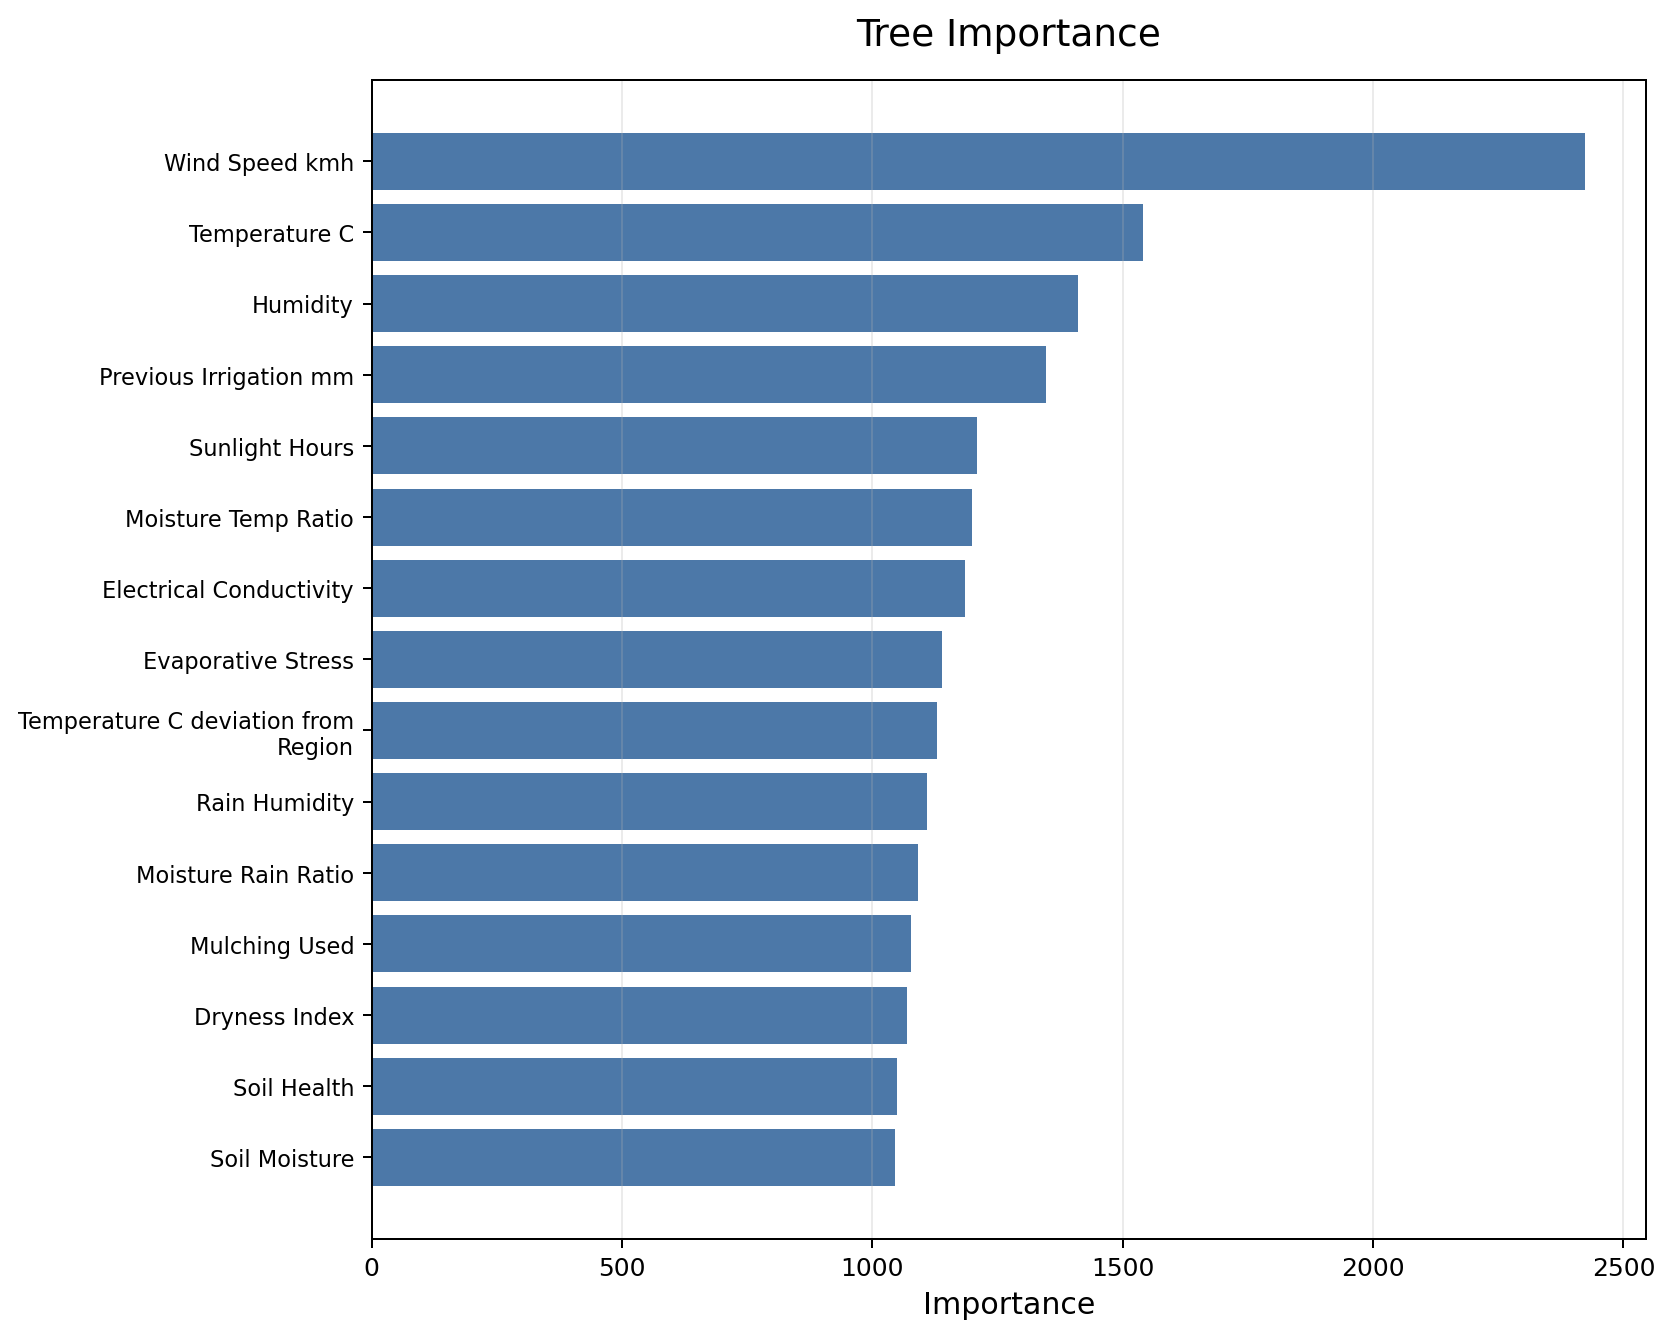

In [29]:
from IPython.display import Image
Image(filename="tree_importance_lgbm_barplot.png")


## Permutation Importance


In [30]:
permutation_importance = pd.read_csv("permutation_importance_lgbm.csv").head(15)
display(permutation_importance)


feature,permutation_importance_mean,permutation_importance_std
Soil_Moisture_mean_by_Crop_Growth_Stage,0.233095,0.004279
Soil_Moisture,0.178237,0.001897
Mulching_Used,0.120666,0.006019
Wind_Speed_kmh,0.119174,0.006364
Temperature_C,0.087321,0.000987
Temperature_C_deviation_from_Region,0.003062,0.001000
Moisture_Temp_Ratio,0.002105,0.000874
Rainfall_mm,0.001660,0.000500
Rainfall_mm_deviation_from_Crop_Type,0.000834,0.000562
Moisture_Rain_Ratio,0.000665,0.000194


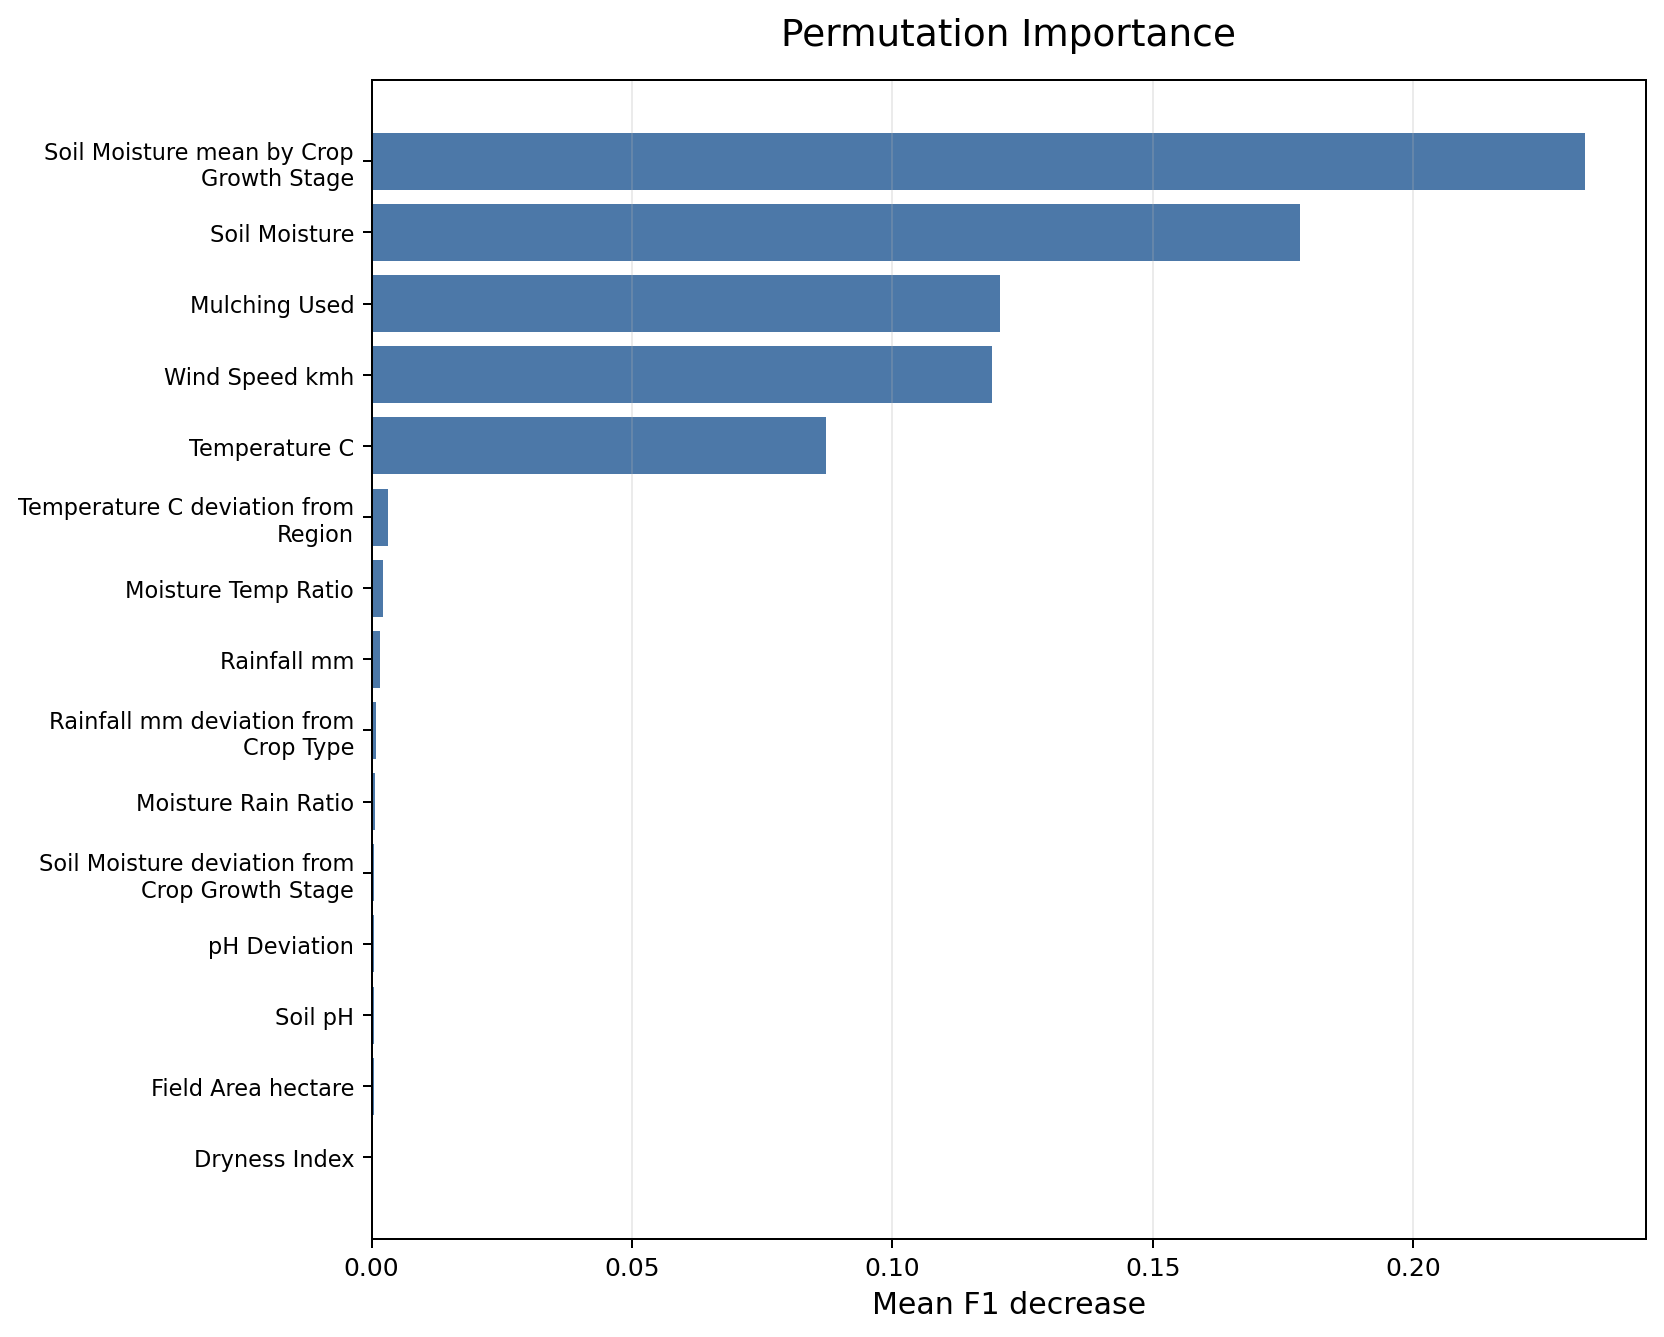

In [31]:
Image(filename="permutation_importance_lgbm_barplot.png")


## LASSO Feature Importance


In [32]:
lasso_importance = pd.read_csv("lasso_l1_feature_importance.csv")
lasso_importance = lasso_importance[lasso_importance["mean_abs_l1_coefficient"] > 0].head(15)
display(lasso_importance)


feature,mean_abs_l1_coefficient
cat__Mulching_Used_Yes,1.704500
num__Soil_Moisture_mean_by_Crop_Growth_Stage,1.386092
cat__Crop_Growth_Stage_Flowering,1.067581
num__Wind_Speed_kmh,0.774988
num__Soil_Moisture,0.505556
num__Temperature_C,0.472951
num__Temperature_C_deviation_from_Region,0.453970
num__Soil_Moisture_deviation_from_Season,0.445620
num__Soil_Moisture_deviation_from_Soil_Type,0.437896
cat__Crop_Growth_Stage_Harvest,0.426245


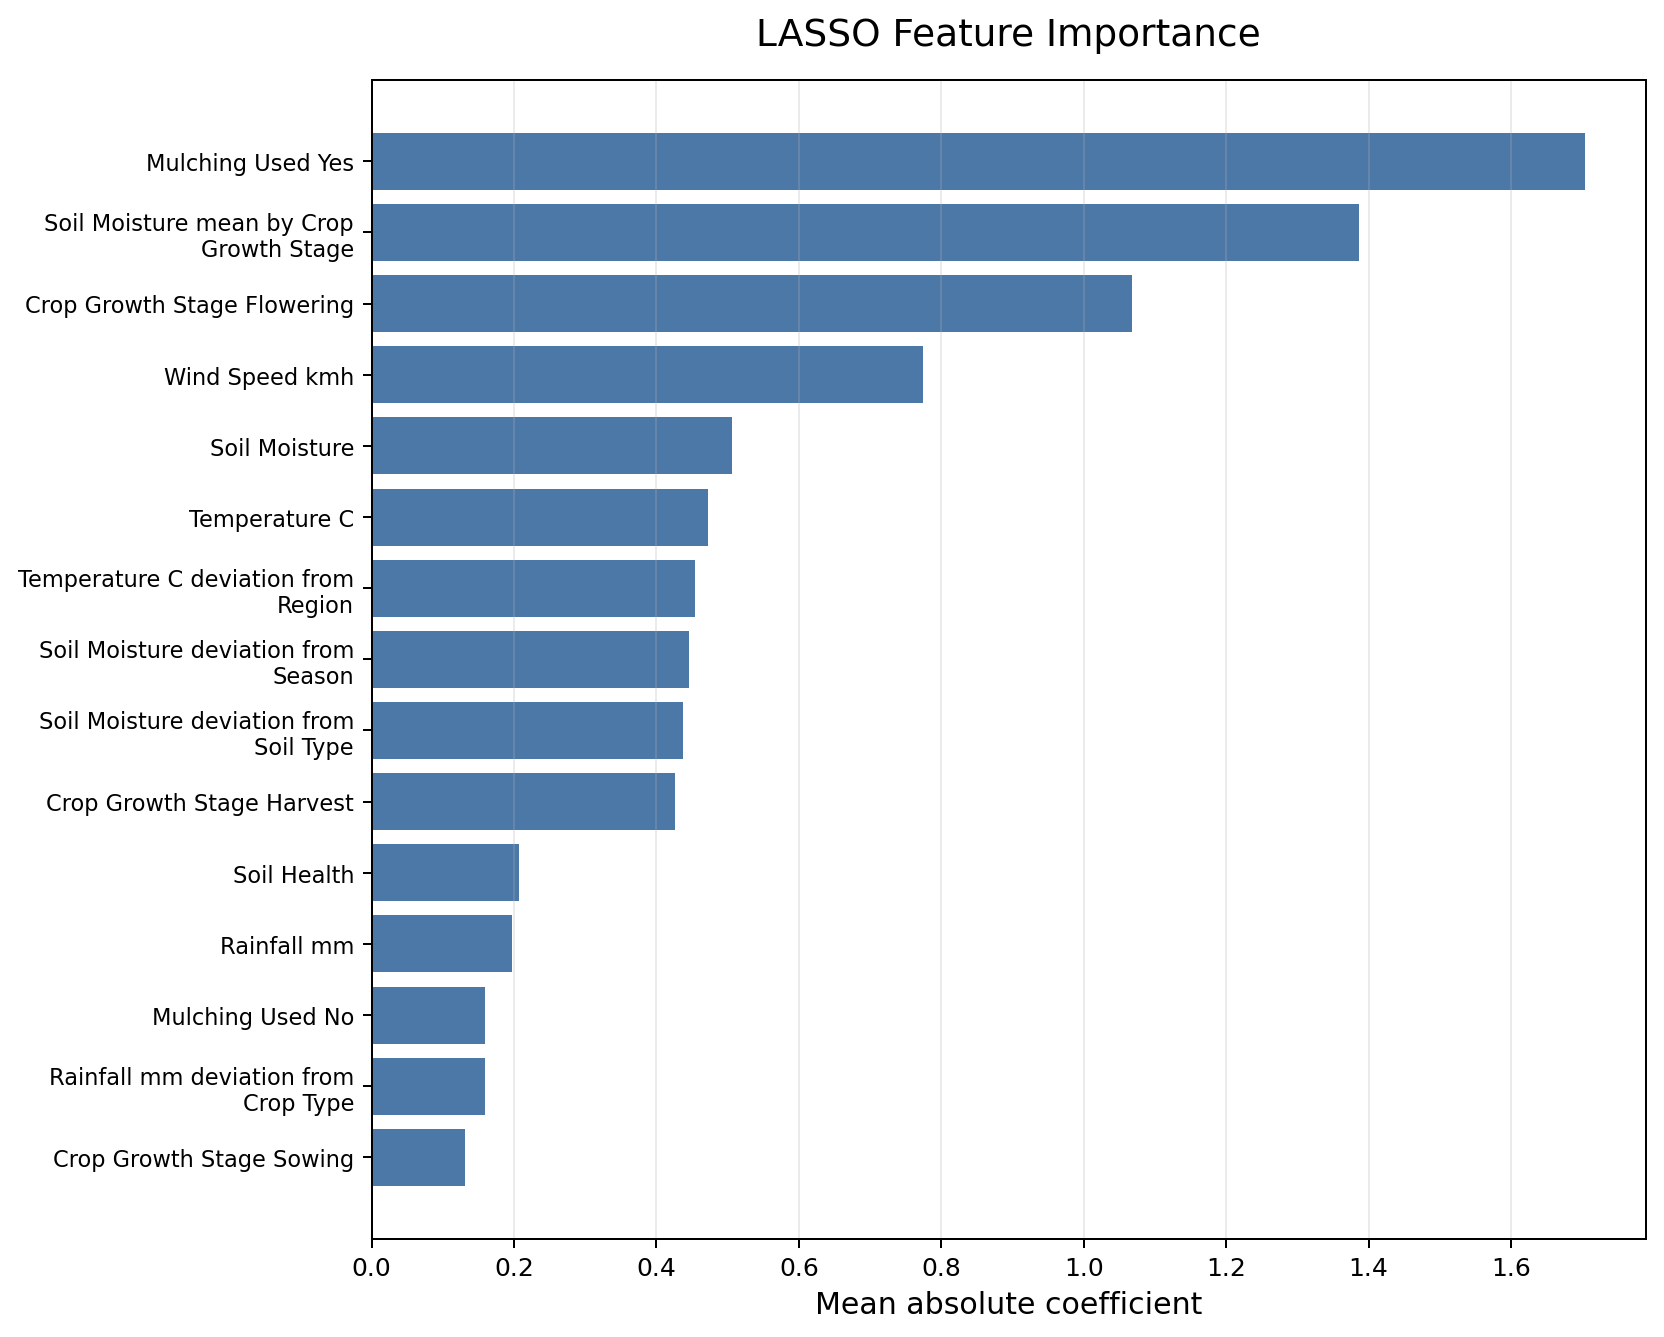

In [33]:
Image(filename="lasso_l1_feature_importance_barplot.png")


## SHAP Bar Plot


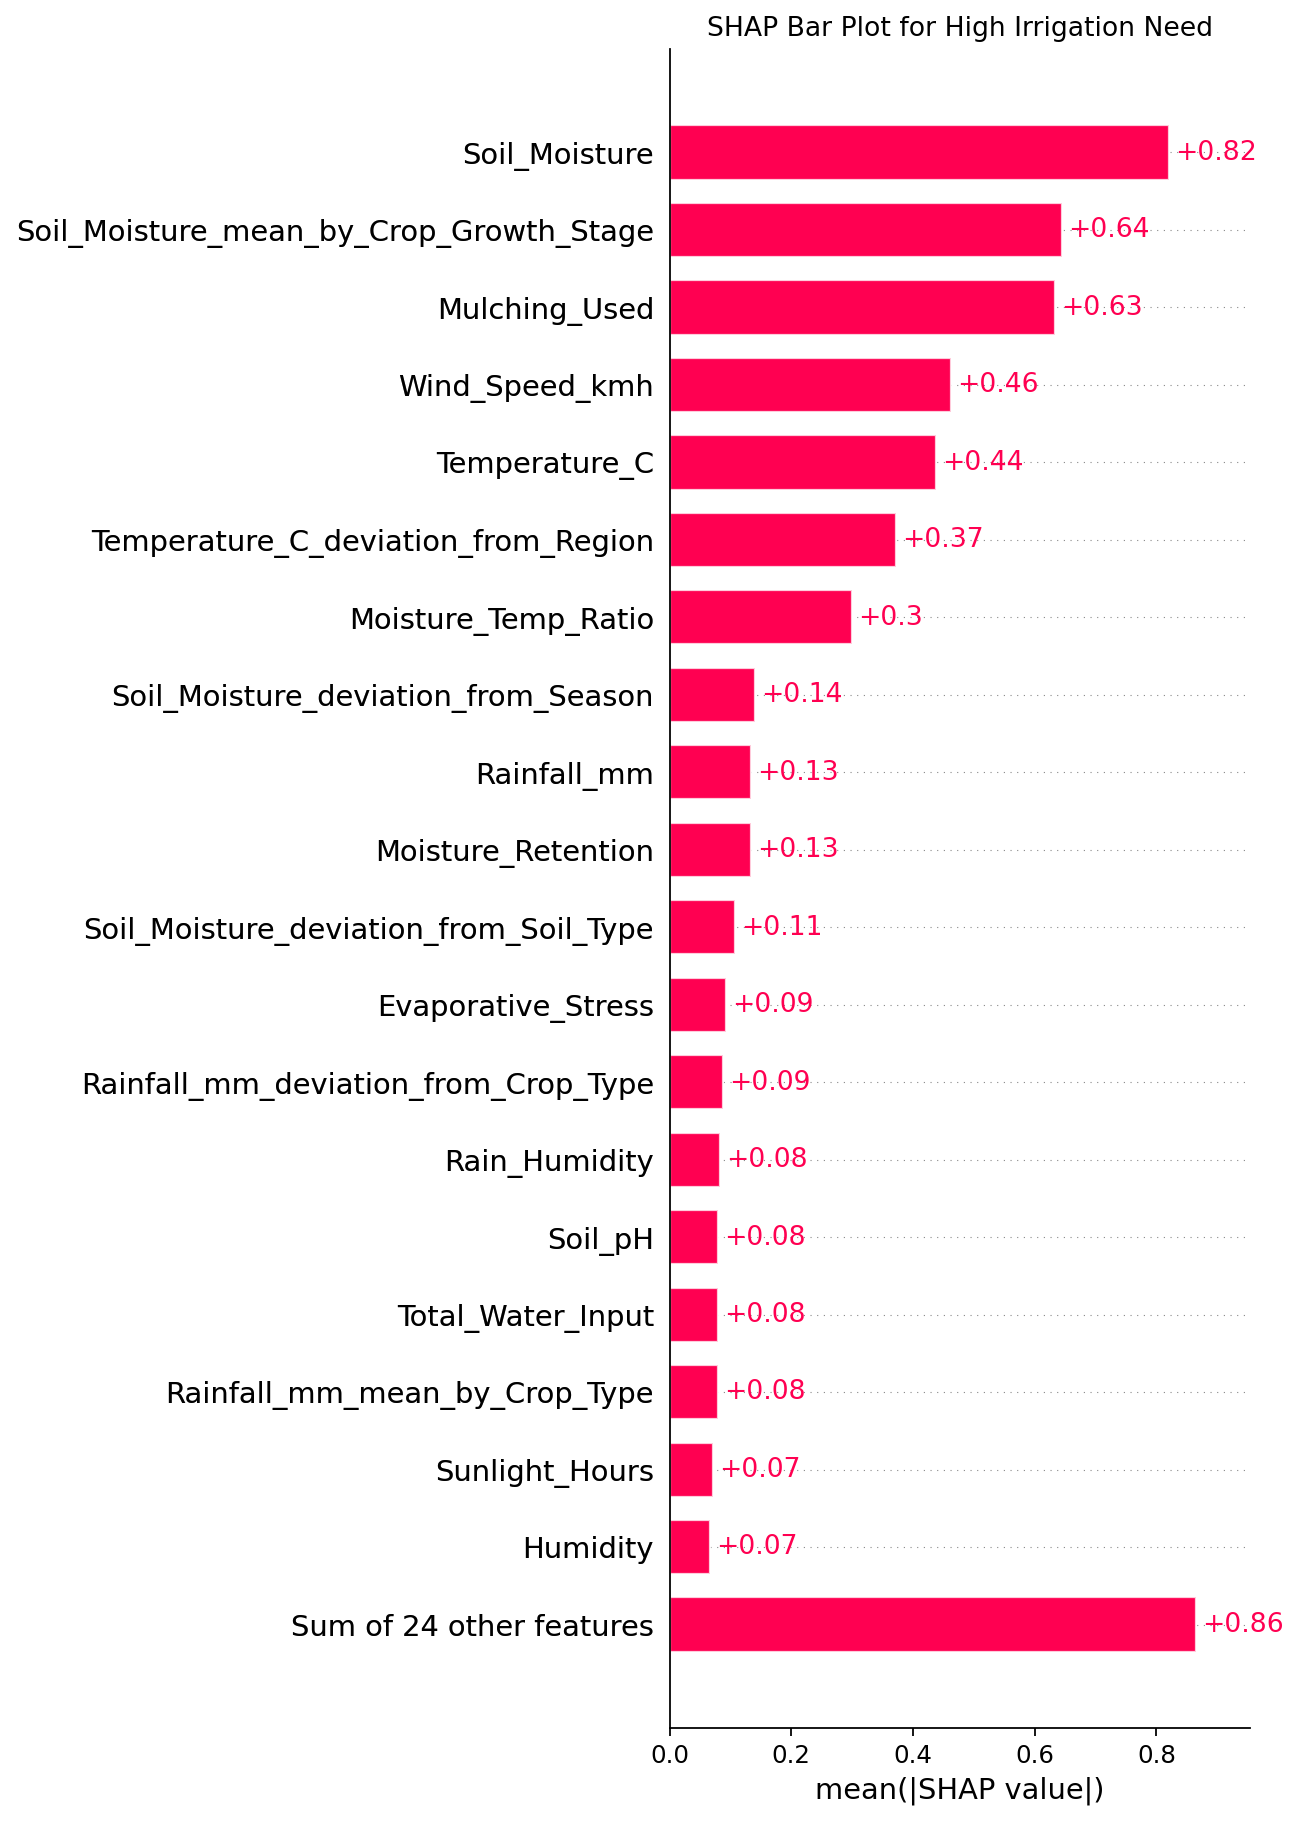

In [34]:
Image(filename="shap_barplot_lgbm_high.png")


## SHAP Beeswarm Plot


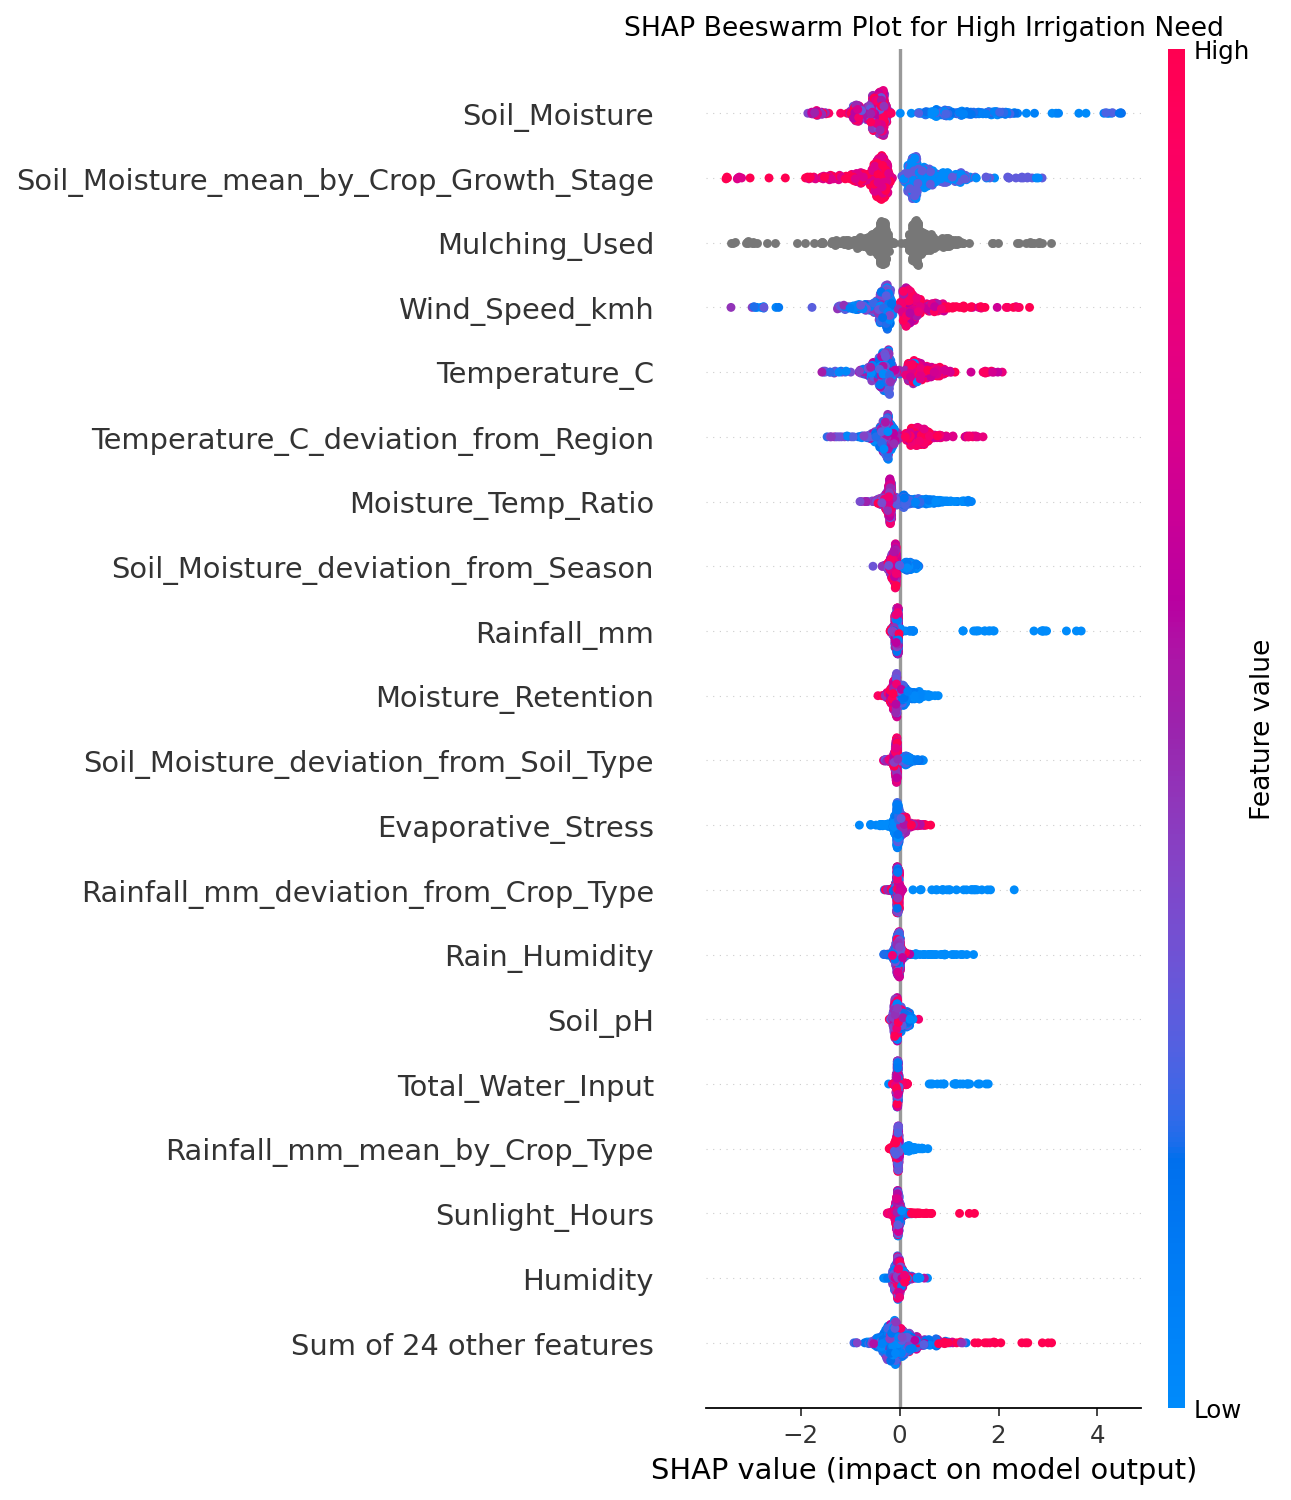

In [35]:
Image(filename="shap_beeswarm_lgbm_high.png")


## SHAP Waterfall Plot


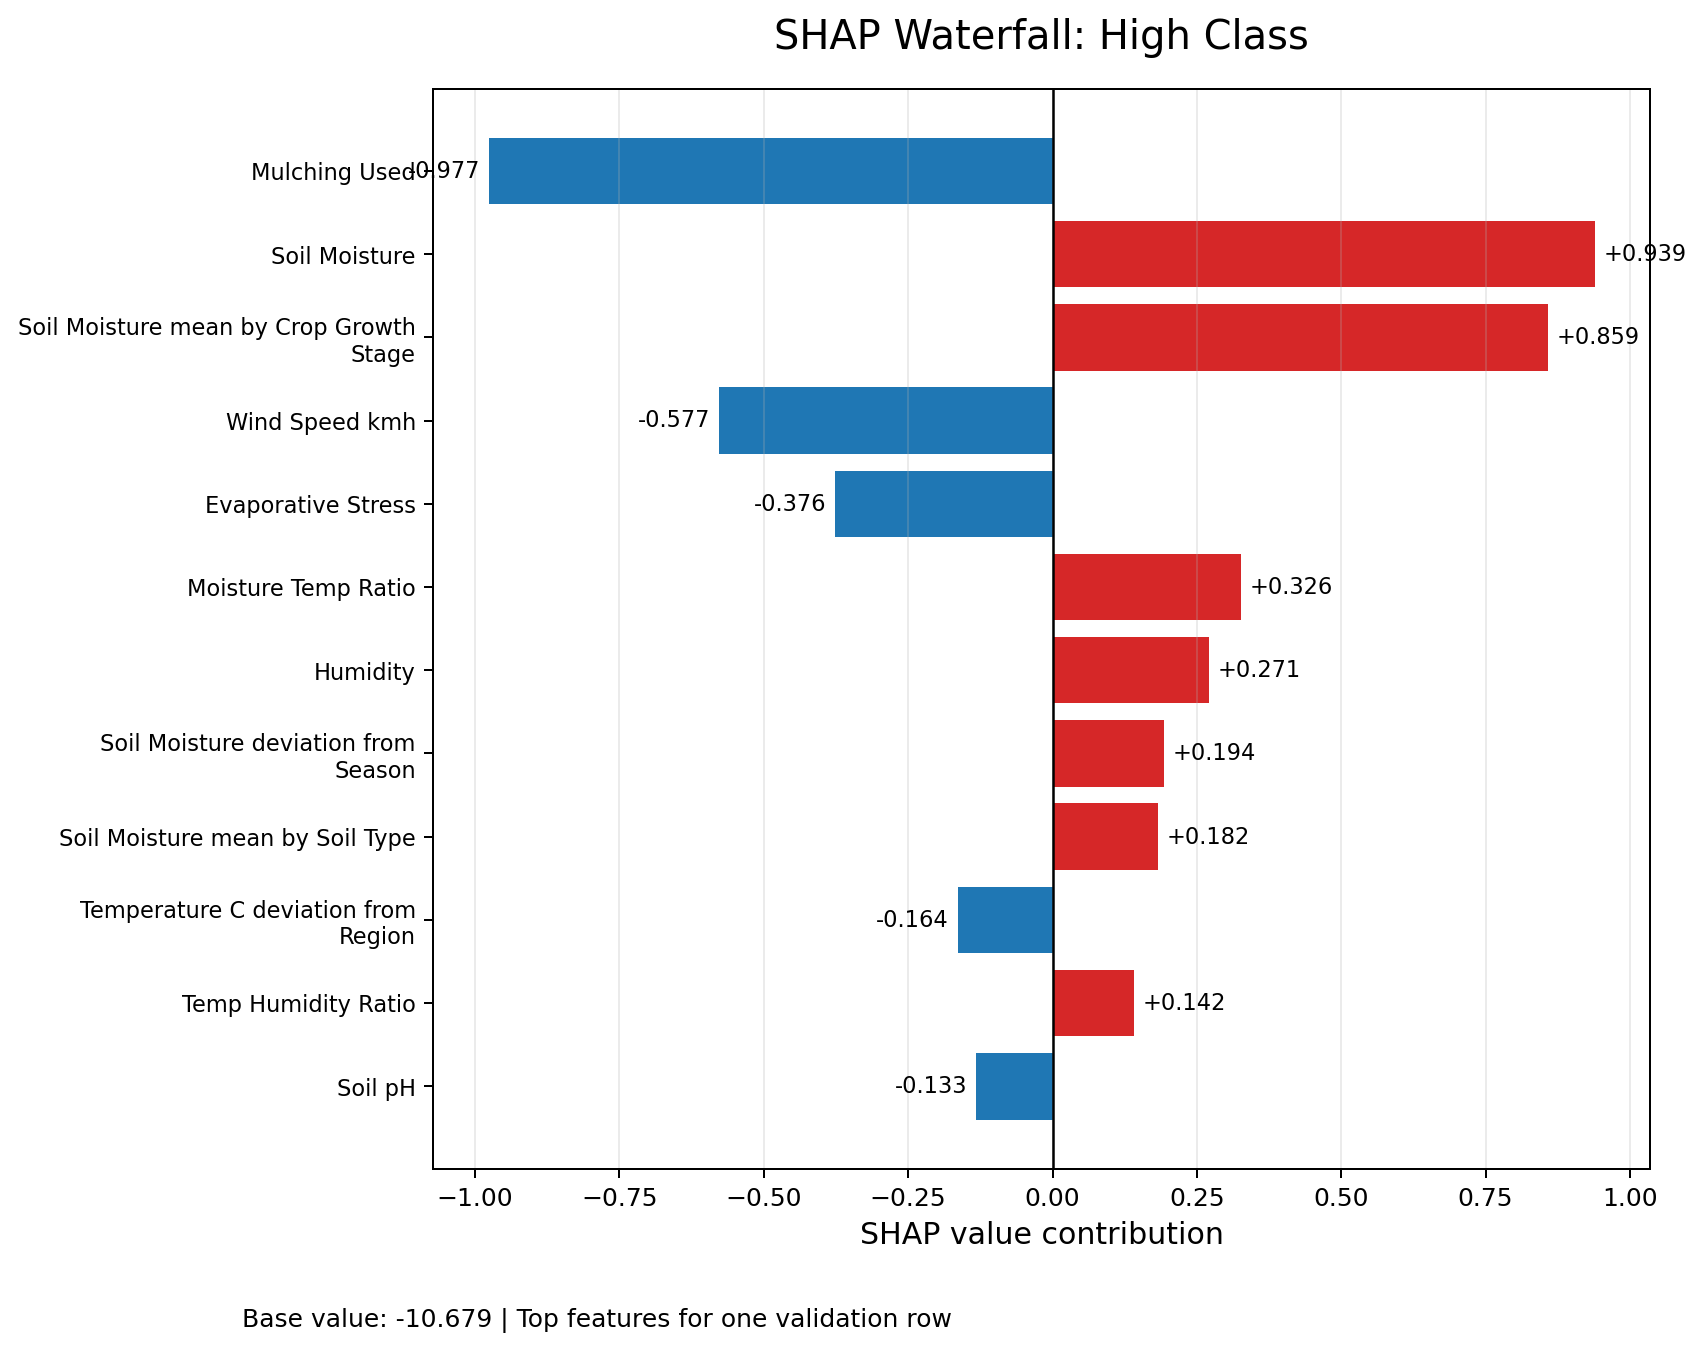

In [36]:
Image(filename="shap_waterfall_lgbm_high.png")


# Final Results

| Rank | Model / Approach | Weighted F1 |
|---:|---|---:|
| 1 | Simple probability average ensemble | 0.985078 |
| 2 | CatBoost | 0.984752 |
| 3 | LightGBM | 0.984723 |
| 4 | HistGradientBoosting | 0.984599 |
| 5 | Stacked logistic meta-model | 0.984102 |

Best submission file: `submission_final_average_optuna_cv.csv`


In [26]:
model_results = pd.read_csv("model_cv_results.csv").sort_values("cv_weighted_f1", ascending=False)
feature_results = pd.read_csv("feature_set_cv_comparison.csv").sort_values("mean_weighted_f1", ascending=False)

display(model_results)
display(feature_results)


model,cv_weighted_f1
Simple probability average,0.985070
LightGBM,0.984806
CatBoost,0.984736
HistGradientBoosting,0.984481
Stacked logistic meta-model fitted OOF,0.984284
Stacked logistic meta-model CV,0.984099


feature_set,num_features,mean_weighted_f1,std_weighted_f1
Base + grouped engineered features,43,0.984903,0.001021
Original features only,19,0.984635,0.001192
Base engineered features,33,0.984569,0.000979


# Discussion

I started by testing several individual models, including Gradient Boosting, Random Forest, LightGBM, and CatBoost. The boosted tree models worked best, so I used them in the final workflow.

For feature engineering, I added water input, per-hectare water, soil stress, weather stress, ratio, interaction, and grouped deviation features. I tested three feature sets with the same model. The best feature set was the full base + grouped engineered set with a weighted F1 score of 0.984903.

For tuning, I used Optuna with stratified cross-validation. I tuned LightGBM, CatBoost, and HistGradientBoosting. Then I stored out-of-fold probabilities and compared individual models, a simple probability average, and stacking.

The best final result was the simple probability average ensemble with a weighted F1 score of 0.985078. This ensemble averaged the predicted class probabilities from LightGBM, CatBoost, and HistGradientBoosting. It performed slightly better than the individual models and the stacked model, so I would submit `submission_final_average_optuna_cv.csv`.

For feature interpretation, I used SHAP plots, tree importance, permutation importance, and LASSO/L1 feature importance. The most useful features were related to soil moisture, crop growth stage, mulching, wind speed, temperature, previous irrigation, and engineered stress features.
